<a href="https://colab.research.google.com/github/huile09/AI.Vietnamese_banknotes/blob/main/AI_Banknotes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Bài 2. Nhận diện tiền Việt Nam**


In [6]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from google.colab import drive
import os
import kagglehub

Tải dữ liệu

In [20]:
path = kagglehub.dataset_download("uylulu/vietnamese-currency-objecdetection-dataset")
print("Đường dẫn bộ dữ liệu xịn mới:", path)

Using Colab cache for faster access to the 'vietnamese-currency-objecdetection-dataset' dataset.
Đường dẫn bộ dữ liệu xịn mới: /kaggle/input/vietnamese-currency-objecdetection-dataset


Tăng cường dữ liệu

In [21]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

data_dir = os.path.join(path, 'dataset')
img_width, img_height = 128, 128
batch_size = 64

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    color_mode='rgb',
    class_mode='categorical',
    subset='training'
)

validation_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    color_mode='rgb',
    class_mode='categorical',
    subset='validation'
)

Found 1972 images belonging to 11 classes.
Found 490 images belonging to 11 classes.


In [22]:
print("Thư mục gốc:", path)
print("Các thư mục con bên trong:", os.listdir(path))

Thư mục gốc: /kaggle/input/vietnamese-currency-objecdetection-dataset
Các thư mục con bên trong: ['dataset']


Thiết kế mạng CNN

In [23]:
from keras.models import Sequential
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Input(shape=(128, 128, 3)),

    Conv2D(32, (3, 3), activation='relu', padding='same'),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(11, activation='softmax')
])

Biên dịch

In [25]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    16,777,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 11)             │         5,643 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,070,379 (65.12 MB)

 Trainable params: 17,070,379 (65.12 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
epochs = 50
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=validation_generator
)

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.0969 - loss: 2.3956 - val_accuracy: 0.1020 - val_loss: 2.3795
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 49s 499ms/step - accuracy: 0.1288 - loss: 2.3291 - val_accuracy: 0.1163 - val_loss: 2.3262
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 15s 492ms/step - accuracy: 0.1496 - loss: 2.2639 - val_accuracy: 0.1592 - val_loss: 2.3184
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 15s 486ms/step - accuracy: 0.1907 - loss: 2.1860 - val_accuracy: 0.1490 - val_loss: 2.3123
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 15s 494ms/step - accuracy: 0.2541 - loss: 1.9739 - val_accuracy: 0.2673 - val_loss: 2.0719
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 16s 504ms/step - accuracy: 0.3078 - loss: 1.8619 - val_accuracy: 0.3571 - val_loss: 1.8354
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 16s 515ms/step - accuracy: 0.3707 - loss: 1.6805 - val_accuracy: 0.3184 - val_loss: 1.9128
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 17s 548ms/step - accuracy: 0.4199 - loss: 1.5649 - val_accurac

In [27]:
from google.colab import drive
drive.mount('/content/drive')

model_path_h5 = '/content/drive/MyDrive/mo_hinh_nhan_dien_tien_50_epochs2.h5'

model.save(model_path_h5)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Test

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step


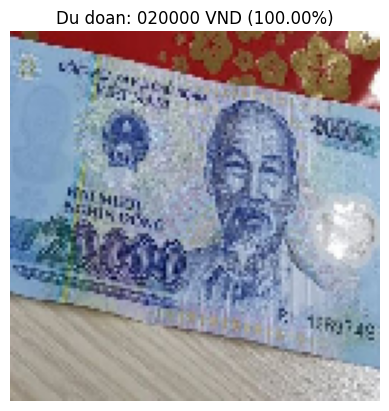

Kết quả nhận diện mệnh giá: 020000 VND
Độ tự tin (Confidence): 100.00%


In [38]:
from keras.models import load_model
from keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

model_path = '/content/drive/MyDrive/mo_hinh_nhan_dien_tien_50_epochs2.h5'
image_path = '/content/Anh3.jpg'

reloaded_model = load_model(model_path)

img_width, img_height = 128, 128
img = load_img(image_path, target_size=(img_width, img_height), color_mode='rgb')

img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0

predictions = reloaded_model.predict(img_array)
predicted_class_idx = np.argmax(predictions, axis=1)[0]
confidence = np.max(predictions) * 100

labels_map = {v: k for k, v in train_generator.class_indices.items()}
predicted_class_name = labels_map[predicted_class_idx]

plt.imshow(img)
plt.title(f"Du doan: {predicted_class_name} VND ({confidence:.2f}%)")
plt.axis('off')
plt.show()

print(f"Kết quả nhận diện mệnh giá: {predicted_class_name} VND")
print(f"Độ tự tin (Confidence): {confidence:.2f}%")

In [39]:
labels_map = {v: k for k, v in train_generator.class_indices.items()}

In [40]:
# In ra thứ tự nhãn chuẩn mà Keras đã tự sắp xếp khi quét thư mục
print(train_generator.class_indices)

{'000200': 0, '000500': 1, '001000': 2, '002000': 3, '005000': 4, '010000': 5, '020000': 6, '050000': 7, '100000': 8, '200000': 9, '500000': 10}
